<a href="https://colab.research.google.com/github/harinijk/YoutubeTrends/blob/main/CSCI4521Project5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Section 1. Data Set & Problem Definition

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.auto import tqdm
from sklearn.metrics import classification_report

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using device: {device}")

Using device: cuda


In [ ]:
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "meruvakodandasuraj/youtube-trending-videos-20202026",
    "trending_videos.csv")

print("shape", df.shape)
print("Columns", df.columns)
display(df.head())

/tmp/ipykernel_2311/1958942737.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'youtube-trending-videos-20202026' dataset.
shape (10000, 34)
Columns Index(['video_id', 'title', 'title_length', 'has_caps_title',
       'has_emoji_title', 'has_question_title', 'channel_name',
       'subscriber_count', 'channel_verified', 'category', 'publish_date',
       'trending_date', 'days_to_trend', 'year', 'month', 'day_of_week',
       'trending_country', 'language', 'duration_seconds', 'views', 'likes',
       'dislikes', 'comments', 'like_view_ratio_pct', 'comment_view_ratio_pct',
       'engagement_score', 'tags', 'tag_count', 'description_length',
       'has_links_description', 'clickbait_score', 'comments_enabled',
       'caption_available', 'made_for_kids'],
      dtype='object')


,video_id,title,title_length,has_caps_title,has_emoji_title,has_question_title,channel_name,subscriber_count,channel_verified,category,...,comment_view_ratio_pct,engagement_score,tags,tag_count,description_length,has_links_description,clickbait_score,comments_enabled,caption_available,made_for_kids
0,VID000001,This survival challenge is UNREAL,33,1,0,0,FireShorts,197893,0,Comedy,...,0.4058,3.8514,adventure|prank|Netflix|Python|space|documenta...,10,500,1,0.664,1,1,0
1,VID000002,Learn Quantum Physics - Complete Beginner Guide,47,0,0,0,FireSports,16191,0,Education,...,0.2300,4.2700,unboxing|Olympics|space|podcast|minecraft|musi...,10,500,1,0.394,1,0,0
2,VID000003,I Spent $1000 on AI tools,25,1,0,0,TruePlus,170530,1,Entertainment,...,1.7400,10.2000,fitness|nature|crypto|unboxing|motivation|NBA ...,7,150,1,0.537,1,1,0
3,VID000004,Ice | Doja Cat ft. Post Malone,30,0,0,0,ProChannel,31268,1,Music,...,0.2400,9.5500,2026|fortnite|PS5,3,300,0,0.552,1,1,0
4,VID000005,The Future of VR is HERE,24,1,0,0,MoonClips,130507,1,Science & Technology,...,0.6640,9.3277,stable diffusion|fortnite|laptop|tech,4,50,0,0.323,1,1,0


In [ ]:
df = df.drop_duplicates()
df = df.dropna(subset=["title","category","engagement_score","clickbait_score","has_caps_title","tag_count"])
df = df[df["engagement_score"] >= 0]


In [ ]:
threshold = df["engagement_score"].median()

df["high_engagement"] = (df["engagement_score"] > threshold).astype(int)
print("Engagement threshold", threshold)
print(df["high_engagement"].value_counts())
print(df["high_engagement"].value_counts(normalize=True))

corr = df.corr(numeric_only=True)["engagement_score"].sort_values(ascending=False)
print("Correlation with engagement_score")
print(corr)


Engagement threshold 7.0764
high_engagement
0    5000
1    5000
Name: count, dtype: int64
high_engagement
0    0.5
1    0.5
Name: proportion, dtype: float64
Correlation with engagement_score
engagement_score          1.000000
like_view_ratio_pct       0.912776
high_engagement           0.776025
comment_view_ratio_pct    0.423545
dislikes                  0.033033
likes                     0.029437
comments                  0.023520
has_emoji_title           0.014397
made_for_kids             0.014065
days_to_trend             0.013485
description_length        0.011486
has_links_description     0.007735
month                     0.006926
has_question_title        0.004801
duration_seconds          0.004171
subscriber_count          0.003876
clickbait_score           0.002857
year                     -0.002515
comments_enabled         -0.002621
caption_available        -0.004065
tag_count                -0.005748
channel_verified         -0.006762
has_caps_title           -0.008716
view

In [ ]:
low_cutoff = df["engagement_score"].quantile(0.30)
high_cutoff = df["engagement_score"].quantile(0.70)

df = df[(df["engagement_score"] <= low_cutoff) | (df["engagement_score"] >= high_cutoff)].copy()

df["high_engagement"] = (df["engagement_score"] >= high_cutoff).astype(int)


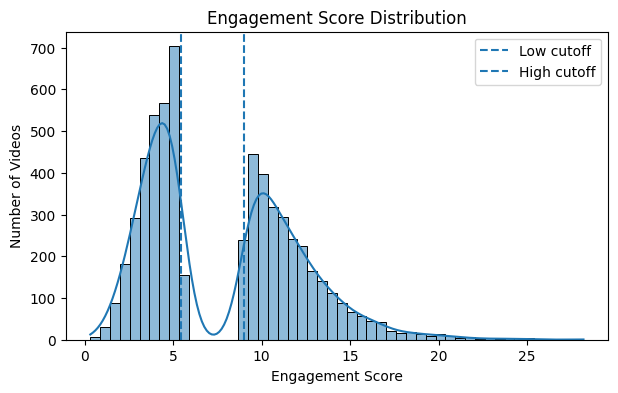

In [ ]:
plt.figure(figsize=(7, 4))
sns.histplot(df["engagement_score"], bins=50, kde=True)
plt.axvline(low_cutoff, linestyle="--", label="Low cutoff")
plt.axvline(high_cutoff, linestyle="--", label="High cutoff")
plt.title("Engagement Score Distribution")
plt.xlabel("Engagement Score")
plt.ylabel("Number of Videos")
plt.legend()
plt.show()

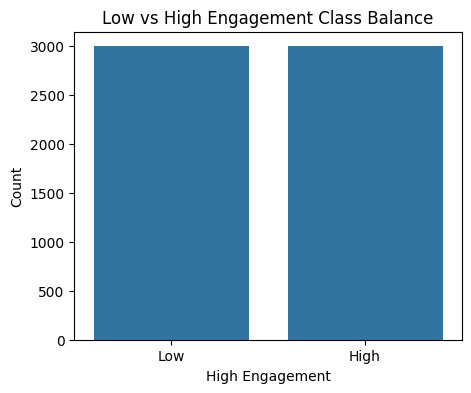

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="high_engagement")
plt.title("Low vs High Engagement Class Balance")
plt.xlabel("High Engagement")
plt.ylabel("Count")
plt.xticks([0, 1], ["Low", "High"])
plt.show()


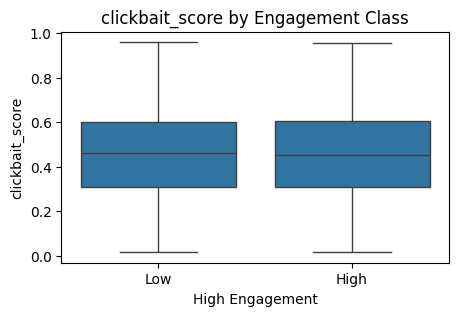

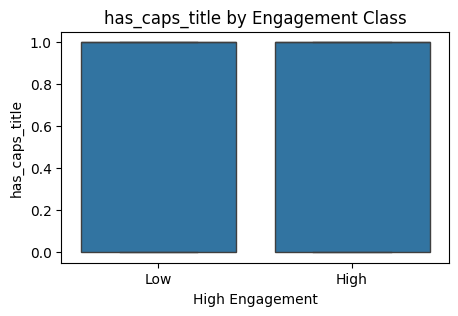

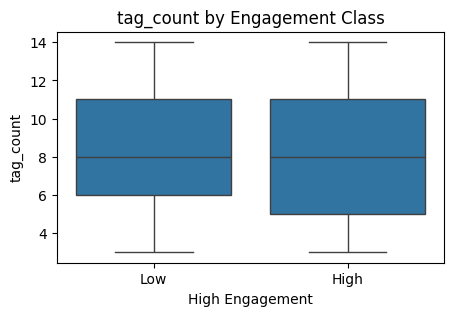

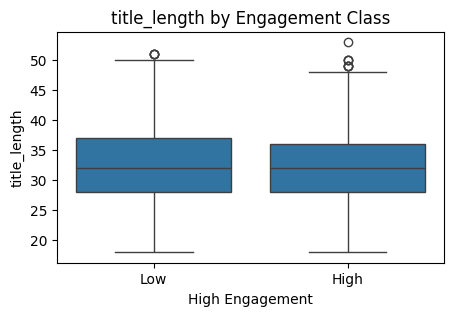

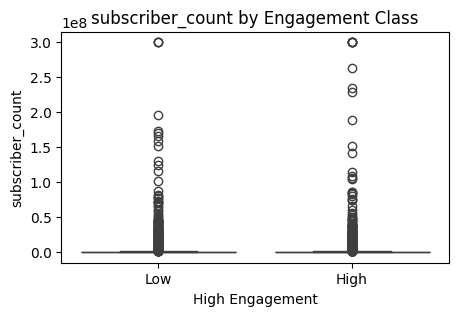

In [ ]:
features_to_check = ["clickbait_score","has_caps_title","tag_count","title_length","subscriber_count"]

for col in features_to_check:
    if col in df.columns:
        plt.figure(figsize=(5, 3))
        sns.boxplot(data=df, x="high_engagement", y=col)
        plt.title(f"{col} by Engagement Class")
        plt.xlabel("High Engagement")
        plt.ylabel(col)
        plt.xticks([0, 1], ["Low", "High"])
        plt.show()

In [ ]:
df = df[["title","category","clickbait_score","has_caps_title","tag_count","engagement_score","high_engagement"]]

display(df.head())

,title,category,clickbait_score,has_caps_title,tag_count,engagement_score,high_engagement
0,This survival challenge is UNREAL,Comedy,0.664,1,10,3.8514,0
1,Learn Quantum Physics - Complete Beginner Guide,Education,0.394,0,10,4.2700,0
2,I Spent $1000 on AI tools,Entertainment,0.537,1,7,10.2000,1
3,Ice | Doja Cat ft. Post Malone,Music,0.552,0,3,9.5500,1
4,The Future of VR is HERE,Science & Technology,0.323,1,4,9.3277,1


In [ ]:
train_df, temp_df = train_test_split(df,test_size=0.30,random_state=42,stratify=df["high_engagement"])
val_df, test_df = train_test_split(temp_df,test_size=0.50,random_state=42,stratify=temp_df["high_engagement"])

train_df["text_input"] = ("Title: " + train_df["title"].astype(str) +" Category: " + train_df["category"].astype(str) +" ClickbaitScore: " + train_df["clickbait_score"].astype(str) +" TagsCount: " + train_df["tag_count"].astype(str))
val_df["text_input"] = ("Title: " + val_df["title"].astype(str) + " Category: " + val_df["category"].astype(str) + " ClickbaitScore: " + val_df["clickbait_score"].astype(str) + " TagsCount: " + val_df["tag_count"].astype(str))
test_df["text_input"] = ("Title: " + test_df["title"].astype(str) +" Category: " + test_df["category"].astype(str) +" ClickbaitScore: " + test_df["clickbait_score"].astype(str) +" TagsCount: " + test_df["tag_count"].astype(str))

print("Split sizes:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain class distribution:")
print(train_df["high_engagement"].value_counts(normalize=True))

print("\nValidation class distribution:")
print(val_df["high_engagement"].value_counts(normalize=True))

print("\nTest class distribution:")
print(test_df["high_engagement"].value_counts(normalize=True))

Split sizes:
Train: 4200
Validation: 900
Test: 900

Train class distribution:
high_engagement
1    0.5
0    0.5
Name: proportion, dtype: float64

Validation class distribution:
high_engagement
0    0.5
1    0.5
Name: proportion, dtype: float64

Test class distribution:
high_engagement
1    0.5
0    0.5
Name: proportion, dtype: float64


In [ ]:
print("Feature summary:")
display(df.describe(include="all").transpose())

Feature summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,6000,1298,You Won't BELIEVE What Happened Next!,154,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,6000,17,Music,872,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clickbait_score,6000.0,NaN,NaN,NaN,0.457938,0.195437,0.016,0.31,0.4575,0.603,0.96
has_caps_title,6000.0,NaN,NaN,NaN,0.651667,0.476482,0.0,0.0,1.0,1.0,1.0
tag_count,6000.0,NaN,NaN,NaN,8.4405,3.440945,3.0,5.0,8.0,11.0,14.0
engagement_score,6000.0,NaN,NaN,NaN,7.885994,4.342166,0.3183,4.14945,7.22185,11.1003,28.1824
high_engagement,6000.0,NaN,NaN,NaN,0.5,0.500042,0.0,0.0,0.5,1.0,1.0


Section 2. Embedding Model + Transfer Learning

In [ ]:
text_col = "text_input"
target_col = "high_engagement"

X_train_text = train_df[text_col].astype(str).values
X_val_text = val_df[text_col].astype(str).values
X_test_text = test_df[text_col].astype(str).values

y_train = train_df[target_col].values.astype(np.float32)
y_val = val_df[target_col].values.astype(np.float32)
y_test = test_df[target_col].values.astype(np.float32)

print("Training text samples:", len(X_train_text))
print("Validation text samples:", len(X_val_text))
print("Testing text samples:", len(X_test_text))

Training text samples: 4200
Validation text samples: 900
Testing text samples: 900


In [ ]:
embedding_model_name = "sentence-transformers/all-MiniLM-L6-v2"

sentence_backbone = SentenceTransformer(embedding_model_name)
print("Embedding model:", embedding_model_name)

X_train_embed = sentence_backbone.encode(X_train_text,convert_to_numpy=True,show_progress_bar=True)

X_val_embed = sentence_backbone.encode(X_val_text,convert_to_numpy=True,show_progress_bar=True)

X_test_embed = sentence_backbone.encode(X_test_text,convert_to_numpy=True,show_progress_bar=True)

X_train_full = X_train_embed
X_val_full = X_val_embed
X_test_full = X_test_embed

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model: sentence-transformers/all-MiniLM-L6-v2


Batches:   0%|          | 0/132 [00:00<?, ?it/s]

Batches:   0%|          | 0/29 [00:00<?, ?it/s]

Batches:   0%|          | 0/29 [00:00<?, ?it/s]

In [ ]:
class EngagementDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]


batch_size = 128

train_dataset = EngagementDataset(X_train_full, y_train)
val_dataset = EngagementDataset(X_val_full, y_val)
test_dataset = EngagementDataset(X_test_full, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class EngagementClassifier(nn.Module):
    def __init__(self, input_size):
        super(EngagementClassifier, self).__init__()

        self.classifier = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.classifier(x).squeeze(1)


input_size = X_train_full.shape[1]

engagement_model = EngagementClassifier(input_size).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(engagement_model.parameters(),lr=0.001,weight_decay=1e-4)

In [ ]:
num_epochs = 30

train_losses = []
val_losses = []
val_accuracies = []

best_val_loss = float("inf")
patience = 10
patience_counter = 0
best_model_state = None

for epoch in range(num_epochs):
    engagement_model.train()
    total_train_loss = 0

    for features, targets in train_loader:
        features = features.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        logits = engagement_model(features)
        loss = criterion(logits, targets)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    engagement_model.eval()
    total_val_loss = 0
    val_preds = []
    val_true = []

    with torch.no_grad():
        for features, targets in val_loader:
            features = features.to(device)
            targets = targets.to(device)

            logits = engagement_model(features)
            loss = criterion(logits, targets)

            total_val_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            val_preds.extend(preds.cpu().numpy())
            val_true.extend(targets.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    val_acc = accuracy_score(val_true, val_preds)
    val_accuracies.append(val_acc)
    print(f"Epoch {epoch} | "
    f"Train Loss: {avg_train_loss:.4f} | "
    f"Val Loss: {avg_val_loss:.4f} | "
    f"Val Accuracy: {val_acc:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = engagement_model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping")
        break

engagement_model.load_state_dict(best_model_state)

Epoch 0 | Train Loss: 0.6947 | Val Loss: 0.6948 | Val Accuracy: 0.5000
Epoch 1 | Train Loss: 0.6939 | Val Loss: 0.6939 | Val Accuracy: 0.4944
Epoch 2 | Train Loss: 0.6934 | Val Loss: 0.6935 | Val Accuracy: 0.4978
Epoch 3 | Train Loss: 0.6930 | Val Loss: 0.6934 | Val Accuracy: 0.4922
Epoch 4 | Train Loss: 0.6925 | Val Loss: 0.6927 | Val Accuracy: 0.5011
Epoch 5 | Train Loss: 0.6918 | Val Loss: 0.6918 | Val Accuracy: 0.4900
Epoch 6 | Train Loss: 0.6911 | Val Loss: 0.6928 | Val Accuracy: 0.5000
Epoch 7 | Train Loss: 0.6916 | Val Loss: 0.6918 | Val Accuracy: 0.4844
Epoch 8 | Train Loss: 0.6905 | Val Loss: 0.6898 | Val Accuracy: 0.5089
Epoch 9 | Train Loss: 0.6897 | Val Loss: 0.6941 | Val Accuracy: 0.4856
Epoch 10 | Train Loss: 0.6884 | Val Loss: 0.6887 | Val Accuracy: 0.5133
Epoch 11 | Train Loss: 0.6869 | Val Loss: 0.6898 | Val Accuracy: 0.4956
Epoch 12 | Train Loss: 0.6873 | Val Loss: 0.6894 | Val Accuracy: 0.4956
Epoch 13 | Train Loss: 0.6875 | Val Loss: 0.6875 | Val Accuracy: 0.5067
Ep

<All keys matched successfully>

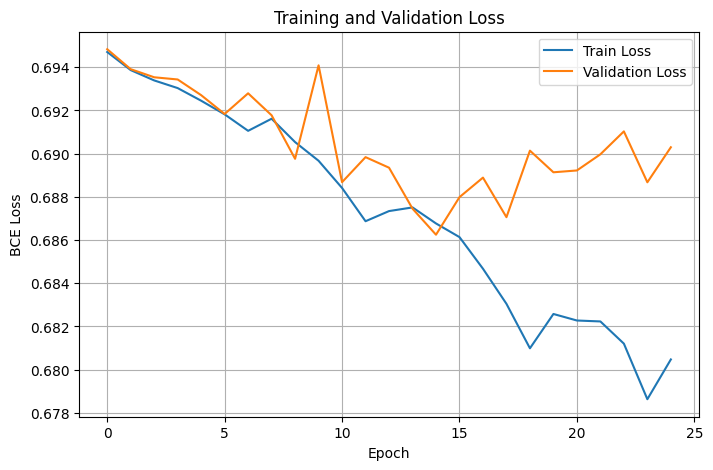

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True)
plt.show()

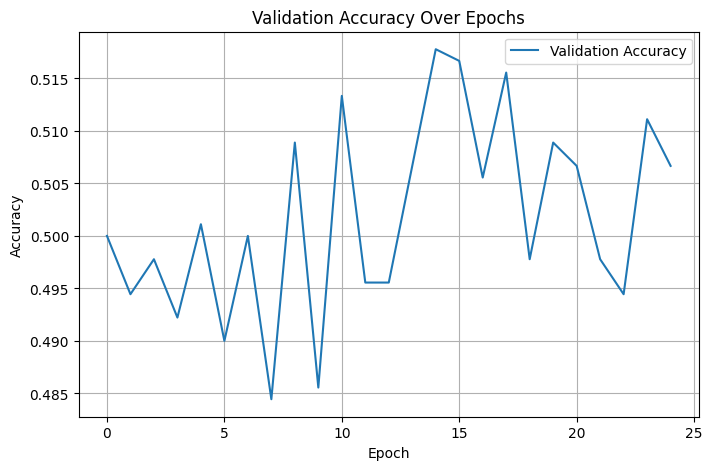

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Validation Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
engagement_model.eval()

all_preds = []
all_probs = []
all_targets = []

with torch.no_grad():
    for features, targets in test_loader:
        features = features.to(device)

        logits = engagement_model(features)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_targets.extend(targets.numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_targets = np.array(all_targets)

accuracy = accuracy_score(all_targets, all_preds)
precision = precision_score(all_targets, all_preds)
recall = recall_score(all_targets, all_preds)
f1 = f1_score(all_targets, all_preds)

print("Test Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Test Results:
Accuracy: 0.48777777777777775
Precision: 0.48655256723716384
Recall: 0.44222222222222224
F1 Score: 0.46332945285215366


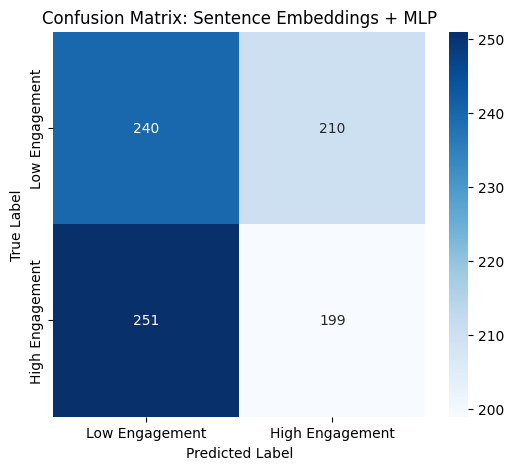

In [ ]:
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Engagement", "High Engagement"],
    yticklabels=["Low Engagement", "High Engagement"]
)

plt.title("Confusion Matrix: Sentence Embeddings + MLP")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
results_df = test_df.copy()

results_df["actual_label"] = all_targets
results_df["predicted_label"] = all_preds
results_df["predicted_probability_high"] = all_probs

failure_cases = results_df[
    results_df["actual_label"] != results_df["predicted_label"]
]

print("Number of failure cases:", len(failure_cases))

display(failure_cases[[
    "title",
    "category",
    "engagement_score",
    "actual_label",
    "predicted_label",
    "predicted_probability_high"
]].head(10))

Number of failure cases: 461


,title,category,engagement_score,actual_label,predicted_label,predicted_probability_high
5008,INSANE TikTok trends You Have to See,Howto & Style,10.6700,1.0,0.0,0.484037
1479,The Most SHOCKING survival challenge Ever,Entertainment,9.8018,1.0,0.0,0.388700
354,Bad Bunny - Ice [Lyrics],Music,2.7589,0.0,1.0,0.512820
5136,We Found the SATISFYING gadgets,Comedy,4.4419,0.0,1.0,0.556512
9165,How DNA Actually Works,Education,1.2594,0.0,1.0,0.571307
3480,You Won't BELIEVE What Happened Next!,Entertainment,9.7600,1.0,0.0,0.414744
7418,Black Holes Explained in 15 Minutes,Education,2.6066,0.0,1.0,0.555093
2700,Baldur's Gate 3 but I can only go UP,Gaming,12.9738,1.0,0.0,0.476889
8684,🔥 SZA NEW SONG 2020,Music,14.2000,1.0,0.0,0.325127
2072,Soccer Highlights | Olympics,Sports,11.5418,1.0,0.0,0.487002


In [ ]:
failure_cases["confidence"] = abs(failure_cases["predicted_probability_high"] - 0.5)

confident_wrong = failure_cases.sort_values("confidence",ascending=False)

display(confident_wrong[[
    "title",
    "category",
    "engagement_score",
    "actual_label",
    "predicted_label",
    "predicted_probability_high",
    "confidence"
]].head(10))

/tmp/ipykernel_2311/2003952508.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  failure_cases["confidence"] = abs(failure_cases["predicted_probability_high"] - 0.5)


,title,category,engagement_score,actual_label,predicted_label,predicted_probability_high,confidence
8619,Why Schools Don't Teach Coding,Education,12.8334,1.0,0.0,0.296158,0.203842
8246,SZA - Ice (Official Music Video),Music,9.4133,1.0,0.0,0.309663,0.190337
5661,Ice | SZA ft. Cardi B,Music,14.7313,1.0,0.0,0.319240,0.180760
3304,We Found the EPIC survival challenge,People & Blogs,10.0288,1.0,0.0,0.320666,0.179334
8346,Charli D'Amelio FINALLY Reveals The Truth,Entertainment,10.1688,1.0,0.0,0.324180,0.175820
8684,🔥 SZA NEW SONG 2020,Music,14.2000,1.0,0.0,0.325127,0.174873
9731,We Found the EPIC mystery box,Howto & Style,12.0971,1.0,0.0,0.333896,0.166104
5307,We Found the EPIC mystery box,Shows,10.0586,1.0,0.0,0.334180,0.165820
1426,SZA - Ice [Lyrics],Music,11.2659,1.0,0.0,0.340297,0.159703
4140,Elden Ring but it's CURSED,Gaming,18.2180,1.0,0.0,0.345310,0.154690


Section 3. Large-Language Model and Section 4. Evaluation

In [ ]:
qwen_model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(qwen_model_name)

qwen_model = AutoModelForCausalLM.from_pretrained( qwen_model_name, torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32, device_map="auto")
qwen_model.eval()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

In [ ]:
qwen_prompt_template = """
You are a binary classifier.

Predict whether this YouTube video will have high engagement.

Respond with only: 0 or 1

0 = Low Engagement
1 = High Engagement

Title: {title}
Category: {category}
"""
def parse_label(text: str):
    cleaned = text.strip()

    if cleaned == "1":
        return 1
    elif cleaned == "0":
        return 0

    return "unknown"

def query_qwen(prompt):
    messages = [{"role": "system","content": "You are a careful classifier. Return only 0 or 1."},{"role": "user","content": prompt}]

    text = tokenizer.apply_chat_template(messages,tokenize=False,add_generation_prompt=True)

    inputs = tokenizer(text, return_tensors="pt").to(qwen_model.device)

    with torch.no_grad():
        outputs = qwen_model.generate(**inputs,max_new_tokens=1,do_sample=False)

    response = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:],skip_special_tokens=True).strip()

    return response

sample_size = min(200, len(test_df))

qwen_df = test_df.sample(n=sample_size, random_state=42).copy()
qwen_records = []

print(f"Evaluating Qwen on {sample_size} test examples")

for _, row in tqdm(qwen_df.iterrows(), total=len(qwen_df)):
    prompt = qwen_prompt_template.format(title=row["title"],category=row["category"])

    raw_output = query_qwen(prompt)
    pred_label = parse_label(raw_output)

    qwen_records.append({
        "title": row["title"],
        "category": row["category"],
        "engagement_score": row["engagement_score"],
        "true_label": int(row["high_engagement"]),
        "pred_label": pred_label,
        "raw_output": raw_output
    })

qwen_results = pd.DataFrame(qwen_records)

display(qwen_results.head())

Evaluating Qwen on 200 test examples


  0%|          | 0/200 [00:00<?, ?it/s]

,title,category,engagement_score,true_label,pred_label,raw_output
0,iPhone 17 Review - Is It Worth It?,Science & Technology,3.8797,0,1,1
1,We Tried mystery box For 24 Hours,Entertainment,5.2606,0,1,1
2,Top 10 Boxing Moments of 2022,Sports,1.5138,0,1,1
3,We Found the CRAZY luxury items,Nonprofits & Activism,18.3207,1,1,1
4,We Found the SATISFYING gadgets,Shorts,4.1584,0,1,1


In [ ]:
unknown_mask = qwen_results["pred_label"] == "unknown"

print("Total Qwen predictions:", len(qwen_results))
print("Unknown predictions:", unknown_mask.sum())

qwen_valid = qwen_results[~unknown_mask].copy()

qwen_valid["pred_label"] = qwen_valid["pred_label"].astype(int)
qwen_valid["true_label"] = qwen_valid["true_label"].astype(int)

y_true_qwen = qwen_valid["true_label"].values
y_pred_qwen = qwen_valid["pred_label"].values

qwen_accuracy = accuracy_score(y_true_qwen, y_pred_qwen)
qwen_precision = precision_score(y_true_qwen, y_pred_qwen)
qwen_recall = recall_score(y_true_qwen, y_pred_qwen)
qwen_f1 = f1_score(y_true_qwen, y_pred_qwen)

print("Qwen Test Results:")
print("Accuracy:", qwen_accuracy)
print("Precision:", qwen_precision)
print("Recall:", qwen_recall)
print("F1 Score:", qwen_f1)

Total Qwen predictions: 200
Unknown predictions: 0
Qwen Test Results:
Accuracy: 0.485
Precision: 0.49222797927461137
Recall: 0.95
F1 Score: 0.6484641638225256


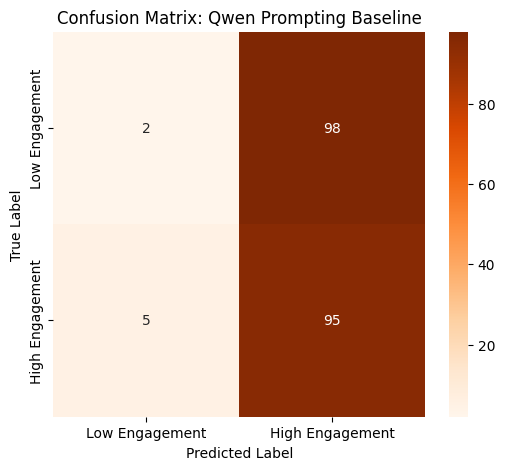

In [ ]:
cm_qwen = confusion_matrix(y_true_qwen, y_pred_qwen)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_qwen,annot=True,fmt="d",cmap="Oranges", xticklabels=["Low Engagement", "High Engagement"],yticklabels=["Low Engagement", "High Engagement"])

plt.title("Confusion Matrix: Qwen Prompting Baseline")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["SentenceTransformer + MLP","Qwen"],
    "Accuracy": [accuracy, qwen_accuracy],
    "Precision": [precision,qwen_precision],
    "Recall": [recall,qwen_recall],
    "F1 Score": [f1,qwen_f1]
})

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,SentenceTransformer + MLP,0.487778,0.486553,0.442222,0.463329
1,Qwen/Qwen2.5-0.5B-Instruct,0.485000,0.492228,0.950000,0.648464


In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["SentenceTransformer + MLP","Qwen/Qwen2.5-0.5B-Instruct"],
    "Accuracy": [accuracy, qwen_accuracy],
    "Precision": [precision,qwen_precision],
    "Recall": [recall,qwen_recall],
    "F1 Score": [f1,qwen_f1]
})

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,SentenceTransformer + MLP,0.487778,0.486553,0.442222,0.463329
1,Qwen/Qwen2.5-0.5B-Instruct,0.485000,0.492228,0.950000,0.648464


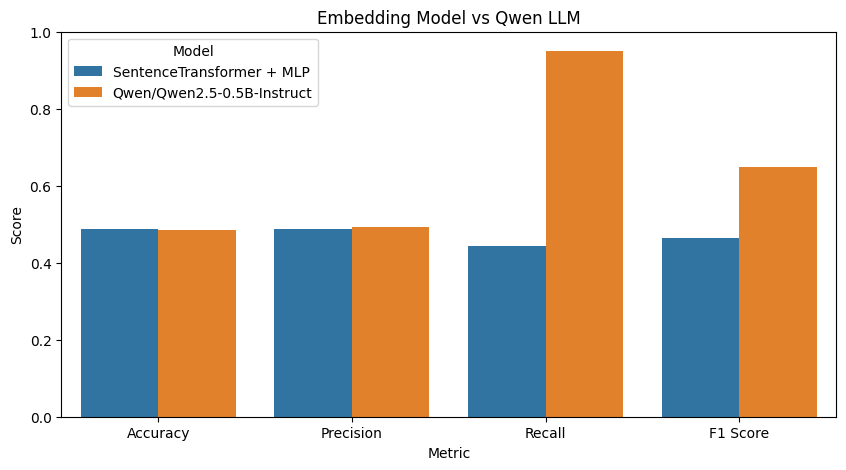

In [ ]:
plot_df = comparison_df.melt(id_vars="Model",var_name="Metric",value_name="Score")

plt.figure(figsize=(10, 5))

sns.barplot(data=plot_df,x="Metric",y="Score",hue="Model")

plt.title("Embedding Model vs Qwen LLM")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Metric")

plt.show()

In [ ]:
print("SentenceTransformer + MLP Classification Report")

print(classification_report(all_targets,all_preds,target_names=["Low Engagement","High Engagement"],zero_division=0))
print("Qwen Classification Report")
print(classification_report(y_true_qwen,y_pred_qwen,target_names=["Low Engagement","High Engagement"],zero_division=0))

SentenceTransformer + MLP Classification Report
                 precision    recall  f1-score   support

 Low Engagement       0.49      0.53      0.51       450
High Engagement       0.49      0.44      0.46       450

       accuracy                           0.49       900
      macro avg       0.49      0.49      0.49       900
   weighted avg       0.49      0.49      0.49       900

Qwen Classification Report
                 precision    recall  f1-score   support

 Low Engagement       0.29      0.02      0.04       100
High Engagement       0.49      0.95      0.65       100

       accuracy                           0.48       200
      macro avg       0.39      0.48      0.34       200
   weighted avg       0.39      0.48      0.34       200



In [ ]:
embedding_failures = results_df[results_df["actual_label"] != results_df["predicted_label"]]

print("Embedding failure cases:", len(embedding_failures))

display(embedding_failures[["title","category","engagement_score","actual_label","predicted_label"]].head(10))

Embedding failure cases: 461


,title,category,engagement_score,actual_label,predicted_label
5008,INSANE TikTok trends You Have to See,Howto & Style,10.6700,1.0,0.0
1479,The Most SHOCKING survival challenge Ever,Entertainment,9.8018,1.0,0.0
354,Bad Bunny - Ice [Lyrics],Music,2.7589,0.0,1.0
5136,We Found the SATISFYING gadgets,Comedy,4.4419,0.0,1.0
9165,How DNA Actually Works,Education,1.2594,0.0,1.0
3480,You Won't BELIEVE What Happened Next!,Entertainment,9.7600,1.0,0.0
7418,Black Holes Explained in 15 Minutes,Education,2.6066,0.0,1.0
2700,Baldur's Gate 3 but I can only go UP,Gaming,12.9738,1.0,0.0
8684,🔥 SZA NEW SONG 2020,Music,14.2000,1.0,0.0
2072,Soccer Highlights | Olympics,Sports,11.5418,1.0,0.0


In [ ]:
qwen_failures = qwen_valid[qwen_valid["true_label"] != qwen_valid["pred_label"]]
print("Qwen failure cases:", len(qwen_failures))

display(qwen_failures[["title","category","engagement_score","true_label","pred_label","raw_output"]].head(10))

Qwen failure cases: 103


,title,category,engagement_score,true_label,pred_label,raw_output
0,iPhone 17 Review - Is It Worth It?,Science & Technology,3.8797,0,1,1
1,We Tried mystery box For 24 Hours,Entertainment,5.2606,0,1,1
2,Top 10 Boxing Moments of 2022,Sports,1.5138,0,1,1
4,We Found the SATISFYING gadgets,Shorts,4.1584,0,1,1
5,Kai Cenat plays Palworld for the first time,Gaming,4.9239,0,1,1
6,We Found the EPIC luxury items,Nonprofits & Activism,5.3870,0,1,1
7,INSANE TikTok trends You Have to See,People & Blogs,1.5407,0,1,1
8,Ocean | Travis Scott ft. Future,Music,4.6046,0,1,1
9,We Found the EPIC AI tools,Shorts,3.8368,0,1,1
10,EPIC TikTok trends You Have to See,Film & Animation,4.7705,0,1,1
